## 1. Setup and Configuration

In [ ]:
import os
import numpy as np
import cv2
import random
import pandas as pd
import warnings
import seaborn as sns
from collections import Counter

from PIL import Image
import matplotlib.pyplot as plt
from arabic_ocr import ArabicOCR

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration
BASE_PATH = os.getcwd()
DATA_PATH = '/content/drive/MyDrive/ArabicMultiFontsDataset'
MODEL_PATH = os.path.join(BASE_PATH, 'model')
OUTPUT_PATH = os.path.join(BASE_PATH, 'output')

BASE_FILENAME = "1_nice_60000_rows"
BINARY_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".bin")
LABELS_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".txt")

# Image settings
IMAGE_WIDTH = 128
IMAGE_HEIGHT = 32
MAX_TEXT_LENGTH = 32

# Training settings
BATCH_SIZE = 100
# TRAINING_SAMPLES_PER_EPOCH = 5000
# VALIDATION_SAMPLES = 1000
MAX_EPOCHS_NO_IMPROVEMENT = 4

# Create directories
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Binary file: {BINARY_FILE}")
print(f"Labels file: {LABELS_FILE}")
print(f"Image size: {IMAGE_WIDTH}x{IMAGE_HEIGHT}")

Binary file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.bin
Labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
Image size: 128x32


## 2. Extract Images from Binary File

### 2.1 Define Sample Class

In [ ]:
class Sample:
    """Represents a single image sample"""
    def __init__(self, gt_text, image_idx, image_height, image_width,
                 image_size, image_start_position):
        self.gtText = gt_text
        self.imageIdx = image_idx
        self.imageHeight = image_height
        self.imageWidth = image_width
        self.imageSize = image_size
        self.imageStartPosition = image_start_position

print("Sample class defined")

Sample class defined


### 2.2 Parse Labels File

In [ ]:
def parse_labels_file(labels_file):
    """
    Parse labels file and extract image metadata

    Args:
        labels_file: Path to labels file

    Returns:
        List of Sample objects
    """
    samples = []

    print(f"Parsing labels file: {labels_file}")

    with open(labels_file, 'r', encoding='utf-8') as f:
        for line in f:
            # Parse line: ImageIndex:0;StartPosition:0;ImageHeight:32;ImageWidth:128;...;Text:hello;...
            parts = line.strip().split(';')

            if len(parts) < 9:
                continue

            # Extract fields
            image_idx = parts[0].split(':')[1] if ':' in parts[0] else parts[0]
            start_pos = int(parts[1].split(':')[1]) if ':' in parts[1] else 0
            height = int(parts[2].split(':')[1]) if ':' in parts[2] else IMAGE_HEIGHT
            width = int(parts[3].split(':')[1]) if ':' in parts[3] else IMAGE_WIDTH
            size = height * width
            text = parts[8].split(':')[1] if ':' in parts[8] else ''

            samples.append(Sample(text, image_idx, height, width, size, start_pos))

    print(f"✓ Parsed {len(samples)} samples")
    return samples

# Parse labels
samples = parse_labels_file(LABELS_FILE)

Parsing labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
✓ Parsed 60000 samples


### 2.3 Extract Images from Binary File


Extracting sample images...


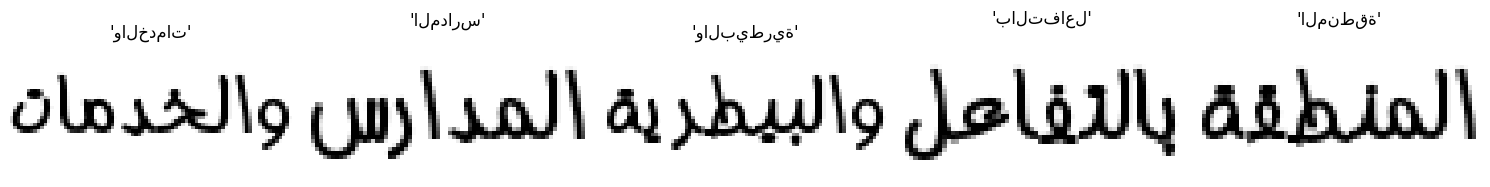

✓ Images extracted successfully


In [ ]:
def extract_image_from_binary(binary_file, sample):
    """
    Extract a single image from binary file

    Args:
        binary_file: Open binary file handle
        sample: Sample object with image metadata

    Returns:
        numpy array (height, width) - grayscale image
    """
    # Seek to image position
    binary_file.seek(sample.imageStartPosition)

    # Read image bytes
    img_bytes = binary_file.read(sample.imageSize)

    # Convert to numpy array
    img = np.frombuffer(img_bytes, dtype=np.uint8)
    img = img.reshape(sample.imageHeight, sample.imageWidth)

    return img

# Test: Extract and display first 5 images
print("\nExtracting sample images...")

with open(BINARY_FILE, 'rb') as f:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):
        img = extract_image_from_binary(f, samples[i])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"'{samples[i].gtText}'")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("✓ Images extracted successfully")

## 3. Preprocess Images

### 3.1 Preprocessing Function

In [ ]:
def preprocess_image(img):
    """
    Preprocess image for model input

    Args:
        img: numpy array (height, width) - grayscale image

    Returns:
        Preprocessed image (width, height) - transposed and normalized
    """
    # Get dimensions
    (h, w) = img.shape

    # Calculate scaling factor
    fx = w / IMAGE_WIDTH
    fy = h / IMAGE_HEIGHT
    f = max(fx, fy)

    # Calculate new size
    new_size = (
        max(min(IMAGE_WIDTH, int(w / f)), 1),
        max(min(IMAGE_HEIGHT, int(h / f)), 1)
    )

    # Resize
    img = cv2.resize(img, new_size)

    # Create target with white background
    target = np.ones([IMAGE_HEIGHT, IMAGE_WIDTH]) * 255
    target[0:new_size[1], 0:new_size[0]] = img

    # Transpose for TensorFlow (width, height)
    img = cv2.transpose(target)

    # Normalize
    (m, s) = cv2.meanStdDev(img)
    m = m[0][0]
    s = s[0][0]
    img = img - m
    img = img / s if s > 0 else img

    return img

print("Preprocessing function defined")

Preprocessing function defined


### 3.2 Test Preprocessing

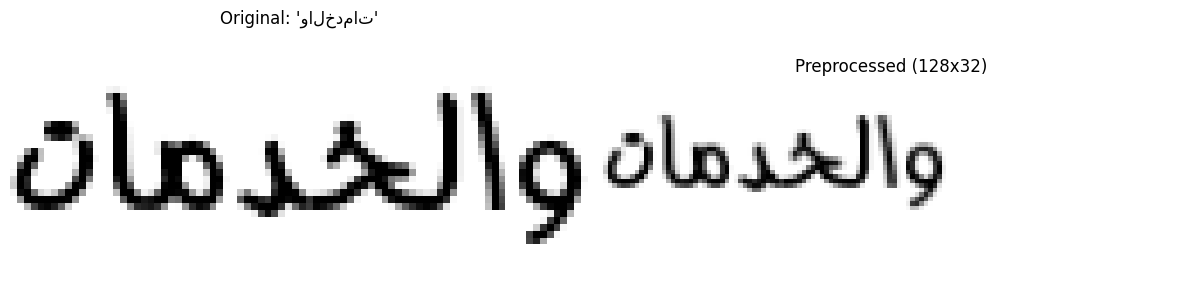

✓ Preprocessing works correctly


In [ ]:
# Test preprocessing on first image
with open(BINARY_FILE, 'rb') as f:
    original = extract_image_from_binary(f, samples[0])
    preprocessed = preprocess_image(original)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(original, cmap='gray')
axes[0].set_title(f"Original: '{samples[0].gtText}'")
axes[0].axis('off')

axes[1].imshow(preprocessed.T, cmap='gray')  # Transpose back for display
axes[1].set_title(f"Preprocessed ({IMAGE_WIDTH}x{IMAGE_HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Preprocessing works correctly")

## 4. Prepare Dataset for Training

### 4.1 Split Dataset

In [ ]:
# Shuffle samples
random.shuffle(samples)

total = len(samples)
train_size = int(0.7 * total)
val_size = int(0.05 * total)

train_samples = samples[:train_size]
val_samples = samples[train_size:train_size + val_size]
test_samples = samples[train_size + val_size:]

print(f"Dataset split:")
print(f"  Training:   {len(train_samples)} samples")
print(f"  Validation: {len(val_samples)} samples")
print(f"  Testing:    {len(test_samples)} samples")

Dataset split:
  Training:   42000 samples
  Validation: 3000 samples
  Testing:    15000 samples


### 4.2 Create Character List

In [ ]:
# Extract unique characters from all labels
chars_set = set()
for sample in samples:
    chars_set = chars_set.union(set(list(sample.gtText)))

char_list = ''.join(sorted(list(chars_set)))

# Save character list
char_list_file = os.path.join(OUTPUT_PATH, 'charList.txt')
with open(char_list_file, 'w', encoding='utf-8') as f:
    f.write(char_list)

print(f"✓ Character list created: {len(char_list)} unique characters")
print(f"  Characters: {char_list[:50]}{'...' if len(char_list) > 50 else ''}")
print(f"  Saved to: {char_list_file}")

✓ Character list created: 45 unique characters
  Characters:  ءآأؤإئابةتثجحخدذرزسشصضطظعغـفقكلمنهوىيٱپژڤکگی
  Saved to: /output/charList.txt


### 4.3 Batch Class

In [ ]:
class Batch:
    """Batch of images and labels"""
    def __init__(self, imgs, gt_texts):
        self.imgs = np.array(imgs)
        self.gtTexts = gt_texts

print("Batch class defined")

Batch class defined


### 4.4 Batch Generator

In [ ]:
def get_batch(binary_file, samples, start_idx, batch_size):
    """
    Get a batch of preprocessed images

    Args:
        binary_file: Open binary file handle
        samples: List of Sample objects
        start_idx: Starting index
        batch_size: Batch size

    Returns:
        Batch object
    """
    end_idx = min(start_idx + batch_size, len(samples))

    imgs = []
    texts = []

    for i in range(start_idx, end_idx):
        # Extract image
        img = extract_image_from_binary(binary_file, samples[i])

        # Preprocess
        img = preprocess_image(img)

        imgs.append(img)
        texts.append(samples[i].gtText)

    return Batch(imgs, texts)

# Test batch generation
print("\nTesting batch generation...")
with open(BINARY_FILE, 'rb') as f:
    test_batch = get_batch(f, train_samples, 0, 8)
    print(f"✓ Generated batch: {test_batch.imgs.shape}")
    print(f"  Labels: {test_batch.gtTexts[:3]}...")


Testing batch generation...
✓ Generated batch: (8, 128, 32)
  Labels: ['المساجد', 'والتيلجو', 'المترجم']...


## 5. Train Model

### 5.1 Initialize Model

In [ ]:
# Create model
model = ArabicOCR(
    decoder_type=1,  # 0 = BestPath, 1 = BeamSearch
    must_restore=False,  # Set True to continue training
    dump=False
)

### 5.2 Training Function

In [ ]:
def train_model(model, train_samples, val_samples, binary_file):
    """
    Train the model

    Args:
        model: ArabicOCR2 instance
        train_samples: Training samples
        val_samples: Validation samples
        binary_file: Path to binary file
    """
    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    epoch = 0
    best_loss = float('inf')
    no_improvement = 0

    while True:
        epoch += 1
        print(f"\nEpoch {epoch}")
        print("-" * 70)

        # Shuffle training samples
        random.shuffle(train_samples)

        # Select subset for this epoch
        epoch_samples = train_samples[:TRAINING_SAMPLES_PER_EPOCH]

        # Training
        epoch_losses = []
        num_batches = len(epoch_samples) // BATCH_SIZE

        with open(binary_file, 'rb') as f:
            for batch_idx in range(num_batches):
                start_idx = batch_idx * BATCH_SIZE
                batch = get_batch(f, epoch_samples, start_idx, BATCH_SIZE)

                # Train
                loss = model.train_batch(batch)
                epoch_losses.append(loss)

                if (batch_idx + 1) % 10 == 0:
                    print(f"  Batch {batch_idx + 1}/{num_batches}: Loss = {loss:.4f}")

        avg_loss = np.mean(epoch_losses)
        print(f"\nEpoch {epoch} - Average Loss: {avg_loss:.4f}")

        # Validation
        val_loss = validate_model(model, val_samples, binary_file)
        print(f"Validation Loss: {val_loss:.4f}")

        # Save if improved
        if val_loss < best_loss:
            print("✓ Validation improved! Saving model...")
            model.save()
            best_loss = val_loss
            no_improvement = 0
        else:
            print("✗ No improvement")
            no_improvement += 1

        # Early stopping
        if no_improvement >= MAX_EPOCHS_NO_IMPROVEMENT:
            print(f"\n✓ Training stopped: No improvement for {MAX_EPOCHS_NO_IMPROVEMENT} epochs")
            print(f"  Best validation loss: {best_loss:.4f}")
            break

    print("=" * 70)
    print("TRAINING COMPLETE")
    print("=" * 70)

print("Training function defined")

Training function defined


### 5.3 Validation Function

In [ ]:
def validate_model(model, val_samples, binary_file):
    """
    Validate the model

    Args:
        model: ArabicOCR2 instance
        val_samples: Validation samples
        binary_file: Path to binary file

    Returns:
        Average validation loss
    """
    # Select subset for validation
    val_subset = val_samples[:VALIDATION_SAMPLES]

    losses = []
    num_batches = len(val_subset) // BATCH_SIZE

    with open(binary_file, 'rb') as f:
        for batch_idx in range(num_batches):
            start_idx = batch_idx * BATCH_SIZE
            batch = get_batch(f, val_subset, start_idx, BATCH_SIZE)

            # Inference
            texts, probs = model.infer_batch(batch, calc_probability=True)

            # Calculate loss (negative log probability)
            if probs is not None:
                loss = -np.mean(np.log(probs + 1e-8))
                losses.append(loss)

    return np.mean(losses) if losses else 0.0

print("Validation function defined")

Validation function defined


### 5.4 Run Training

In [ ]:
# Train the model
train_model(model, train_samples, val_samples, BINARY_FILE)


TRAINING

Epoch 1
----------------------------------------------------------------------
  Batch 10/50: Loss = 20.9201
  Batch 20/50: Loss = 20.0254
  Batch 30/50: Loss = 21.0920
  Batch 40/50: Loss = 20.6182
  Batch 50/50: Loss = 19.4958

Epoch 1 - Average Loss: 20.4241
Validation Loss: 6.4336
✓ Validation improved! Saving model...
Model saved to //model/Test Drive Training Process_2.weights.h5

Epoch 2
----------------------------------------------------------------------
  Batch 10/50: Loss = 20.2151
  Batch 20/50: Loss = 19.6930
  Batch 30/50: Loss = 19.5005
  Batch 40/50: Loss = 18.8458
  Batch 50/50: Loss = 19.3438

Epoch 2 - Average Loss: 19.5823
Validation Loss: 8.9556
✗ No improvement

Epoch 3
----------------------------------------------------------------------
  Batch 10/50: Loss = 18.7901
  Batch 20/50: Loss = 18.5386
  Batch 30/50: Loss = 18.5111
  Batch 40/50: Loss = 18.2589
  Batch 50/50: Loss = 19.0177

Epoch 3 - Average Loss: 18.8303
Validation Loss: 8.5958
✗ No impr

## 6. Inference

### 6.1 Load Trained Model

In [ ]:
# Load trained model
inference_model = ArabicOCR(
    decoder_type=1,  # 0 = BestPath, 1 = BeamSearch
    must_restore=True,  # Load saved weights
    dump=False
)

print("✓ Model loaded for inference")

Restoring from //model/Test Drive Training Process_2.weights.h5
✓ Model loaded for inference


### 6.2 Inference on Test Samples

In [ ]:
def infer_samples(model, samples, binary_file, num_samples=10):
    """
    Run inference on samples

    Args:
        model: ArabicOCR2 instance
        samples: List of samples
        binary_file: Path to binary file
        num_samples: Number of samples to test
    """
    print("\n" + "=" * 70)
    print("INFERENCE")
    print("=" * 70)

    # Select random samples
    test_samples = random.sample(samples, min(num_samples, len(samples)))

    with open(binary_file, 'rb') as f:
        for i, sample in enumerate(test_samples):
            # Extract and preprocess
            img = extract_image_from_binary(f, sample)
            preprocessed = preprocess_image(img)

            # Create batch
            batch = Batch([preprocessed], [''])

            # Inference
            texts, probs = model.infer_batch(batch, calc_probability=True)

            recognized = texts[0]
            confidence = probs[0] * 100 if probs is not None else 0

            # Display
            print(f"\nSample {i + 1}:")
            print(f"  Ground Truth: '{sample.gtText}'")
            print(f"  Recognized:   '{recognized}'")
            print(f"  Confidence:   {confidence:.2f}%")
            print(f"  Match: {'✓' if recognized == sample.gtText else '✗'}")

    print("=" * 70)

# Run inference on test samples
infer_samples(inference_model, test_samples, BINARY_FILE, num_samples=10)


INFERENCE

Sample 1:
  Ground Truth: 'للانتداب'
  Recognized:   'ا'
  Confidence:   0.36%
  Match: ✗

Sample 2:
  Ground Truth: 'فاللغات'
  Recognized:   'ا'
  Confidence:   0.36%
  Match: ✗

Sample 3:
  Ground Truth: 'بأنفسهم'
  Recognized:   'ا'
  Confidence:   0.26%
  Match: ✗

Sample 4:
  Ground Truth: 'فينيقية'
  Recognized:   'ا'
  Confidence:   0.39%
  Match: ✗

Sample 5:
  Ground Truth: 'يتقابلان'
  Recognized:   'ا'
  Confidence:   0.31%
  Match: ✗

Sample 6:
  Ground Truth: 'احتلالها'
  Recognized:   'ا'
  Confidence:   0.30%
  Match: ✗

Sample 7:
  Ground Truth: 'الشركات'
  Recognized:   'اا'
  Confidence:   0.17%
  Match: ✗

Sample 8:
  Ground Truth: 'والاعتزاز'
  Recognized:   'اا'
  Confidence:   0.09%
  Match: ✗

Sample 9:
  Ground Truth: 'المحاكمات'
  Recognized:   'اا'
  Confidence:   0.08%
  Match: ✗

Sample 10:
  Ground Truth: 'المؤسسات'
  Recognized:   'اا'
  Confidence:   0.06%
  Match: ✗


### 6.3 Inference with Visualization


Visualizing inference results...


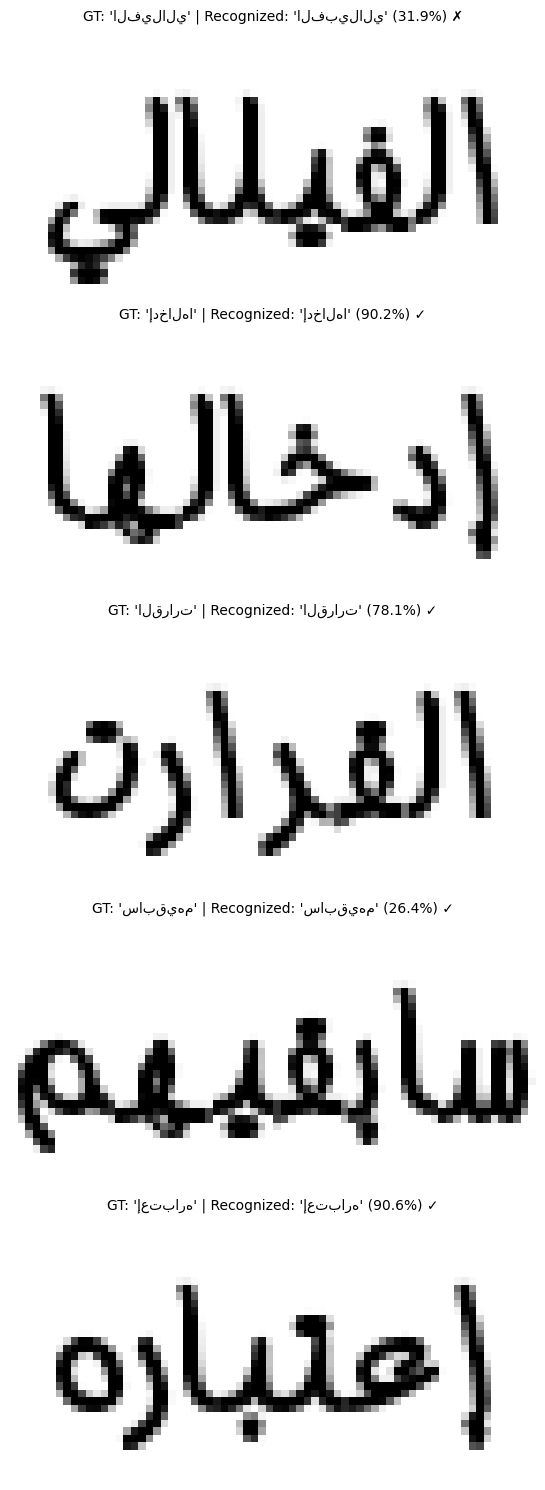

In [ ]:
def infer_and_visualize(model, samples, binary_file, num_samples=5):
    """
    Run inference and visualize results

    Args:
        model: ArabicOCR2 instance
        samples: List of samples
        binary_file: Path to binary file
        num_samples: Number of samples to visualize
    """
    test_samples = random.sample(samples, min(num_samples, len(samples)))

    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 3 * num_samples))
    if num_samples == 1:
        axes = [axes]

    with open(binary_file, 'rb') as f:
        for i, sample in enumerate(test_samples):
            # Extract and preprocess
            img = extract_image_from_binary(f, sample)
            preprocessed = preprocess_image(img)

            # Inference
            batch = Batch([preprocessed], [''])
            texts, probs = model.infer_batch(batch, calc_probability=True)

            recognized = texts[0]
            confidence = probs[0] * 100 if probs is not None else 0

            # Visualize
            axes[i].imshow(img, cmap='gray')
            match = '✓' if recognized == sample.gtText else '✗'
            axes[i].set_title(
                f"GT: '{sample.gtText}' | Recognized: '{recognized}' ({confidence:.1f}%) {match}",
                fontsize=10
            )
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize inference results
print("\nVisualizing inference results...")
infer_and_visualize(inference_model, test_samples, BINARY_FILE, num_samples=5)

### 6.4 Calculate Accuracy Metrics

In [ ]:
def calculate_accuracy(model, samples, binary_file, num_samples=1000):
    """
    Calculate accuracy metrics

    Args:
        model: ArabicOCR2 instance
        samples: List of samples
        binary_file: Path to binary file
        num_samples: Number of samples to evaluate
    """
    try:
        import editdistance
    except ImportError:
        print("Installing editdistance...")
        os.system("pip install editdistance")
        import editdistance

    print("\n" + "=" * 70)
    print("ACCURACY METRICS")
    print("=" * 70)

    # Select samples
    eval_samples = samples[:min(num_samples, len(samples))]

    num_char_err = 0
    num_char_total = 0
    num_word_ok = 0
    num_word_total = 0

    num_batches = len(eval_samples) // BATCH_SIZE

    with open(binary_file, 'rb') as f:
        for batch_idx in range(num_batches):
            start_idx = batch_idx * BATCH_SIZE
            batch = get_batch(f, eval_samples, start_idx, BATCH_SIZE)

            # Inference
            texts, _ = model.infer_batch(batch, calc_probability=False)

            # Calculate metrics
            for i in range(len(texts)):
                gt = batch.gtTexts[i]
                recognized = texts[i]

                # Character error rate
                dist = editdistance.eval(recognized, gt)
                num_char_err += dist
                num_char_total += len(gt)

                # Word accuracy
                num_word_total += 1
                if gt == recognized:
                    num_word_ok += 1

    # Calculate rates
    char_error_rate = (num_char_err / num_char_total * 100) if num_char_total > 0 else 0
    char_accuracy = 100 - char_error_rate
    word_accuracy = (num_word_ok / num_word_total * 100) if num_word_total > 0 else 0

    print(f"Evaluated {num_word_total} samples")
    print(f"\nCharacter Error Rate:   {char_error_rate:.2f}%")
    print(f"Character Accuracy:     {char_accuracy:.2f}%")
    print(f"Word Accuracy:          {word_accuracy:.2f}%")
    print(f"Correct Words:          {num_word_ok}/{num_word_total}")
    print("=" * 70)

    return {
        'char_error_rate': char_error_rate,
        'char_accuracy': char_accuracy,
        'word_accuracy': word_accuracy,
        'correct_words': num_word_ok,
        'total_words': num_word_total
    }

# Calculate accuracy on test set
metrics = calculate_accuracy(inference_model, test_samples, BINARY_FILE, num_samples=1000)


ACCURACY METRICS
Evaluated 1000 samples

Character Error Rate:   5.11%
Character Accuracy:     94.89%
Word Accuracy:          70.60%
Correct Words:          706/1000
